# Step 15 — heatmap: genes × samples at each site, and what the endotypes mean

**Data type: RNA_array** (GSE65391). **Reads:** `step13_model.rds`, `step13_site_{A,B,C}.rds`.
**Writes:** `figures/fig15_RNA_array_genes_by_samples_{A,B,C}.png`.

Each site draws its own samples. The rows, the scaling and the colours are shared, so the three
figures can be read side by side.

**Rows.** For each endotype, the 30 genes whose centroid sits furthest above the average of the other
centroids: the genes that mark it. The coordinator already holds the centroids, so it can choose them.
The six interferon-score genes are added as their own block.

**Columns.** Every sample at the site, all visits, one block per endotype, and the healthy children as
a block of their own.

**Colour.** Expression centred on the pooled discovery mean and divided by the pooled discovery SD of
each gene (both from per-site sums), capped at ±2.5.

**Annotations.** Endotype, interferon score, stage (SLEDAI category of the visit), nephritis class,
the authors' molecular group (`mdg`), visit order within the child, and split. Stage, nephritis and
`mdg` were not used to find the endotypes, so any alignment is a finding, not an input.

In [1]:
source("../src/paths.R")
source("../src/endotypes.R")
source("../src/federation.R")
source("../src/figures.R")
start_log("15")
model <- readRDS(art("step13_model.rds"))
K <- model$k; ce <- model$centroids
EN_COL <- endotype_colours(rownames(ce))
TOP <- 30
markers <- lapply(rownames(ce), function(e) {
  d <- ce[e, ] - colMeans(ce[rownames(ce) != e, , drop = FALSE])
  names(sort(d, decreasing = TRUE))[seq_len(TOP)]
})
names(markers) <- rownames(ce)
ifn6 <- read_gene_set("ifn-type1-6.txt")
rows <- unique(c(unlist(markers), ifn6))
row_block <- factor(ifelse(rows %in% ifn6, "interferon score",
                     paste("marks", rep(names(markers), each = TOP)[match(rows, unlist(markers))])),
                    levels = c(paste("marks", names(markers)), "interferon score"))
markers

$E1
 [1] "ID3"        "HNRNPA1P7"  "ZNF683"     "NELL2"      "CD79B"     
 [6] "CD27"       "LINC00926"  "P2RY10"     "RASGRP1"    "ADARB1"    
[11] "HNRNPA1P10" "LOC652694"  "EEIG1"      "KLF12"      "SERPINA10" 
[16] "IQCB1"      "LEF1"       "WDR54"      "OCIAD2"     "ECI2"      
[21] "COBLL1"     "SLAMF1"     "TCL1A"      "PPP1R16B"   "ITK"       
[26] "NLRC3"      "BCL11B"     "ATP8B2"     "CCR7"       "MAN1C1"    

$E2
 [1] "CEACAM6"   "LOC653600" "LTF"       "ELANE"     "DEFA4"     "OLFM4"    
 [7] "CAMP"      "BPI"       "ARG1"      "AZU1"      "CEACAM8"   "DEFA1B"   
[13] "TCN1"      "GYPB"      "ITLN1"     "DEFA3"     "RAP1GAP"   "MPO"      
[19] "ORM1"      "RNASE3"    "PGLYRP1"   "CA1"       "MMP9"      "VWCE"     
[25] "RETN"      "CTSG"      "GYPE"      "RNF10"     "LCN2"      "RUNDC3A"

In [2]:
# pooled mean and SD of the row genes over discovery samples, from per-site sums
ps <- pool_suff(lapply(SITES, function(s) {
  d <- readRDS(site_file("13", s)); j <- d$meta$split == "discovery"
  send(site_suff(d$E[rows, j]), s, "row-gene sums, discovery", sum(j))
}))
row_mean <- ps$mean; row_sd <- sqrt(ps$var)

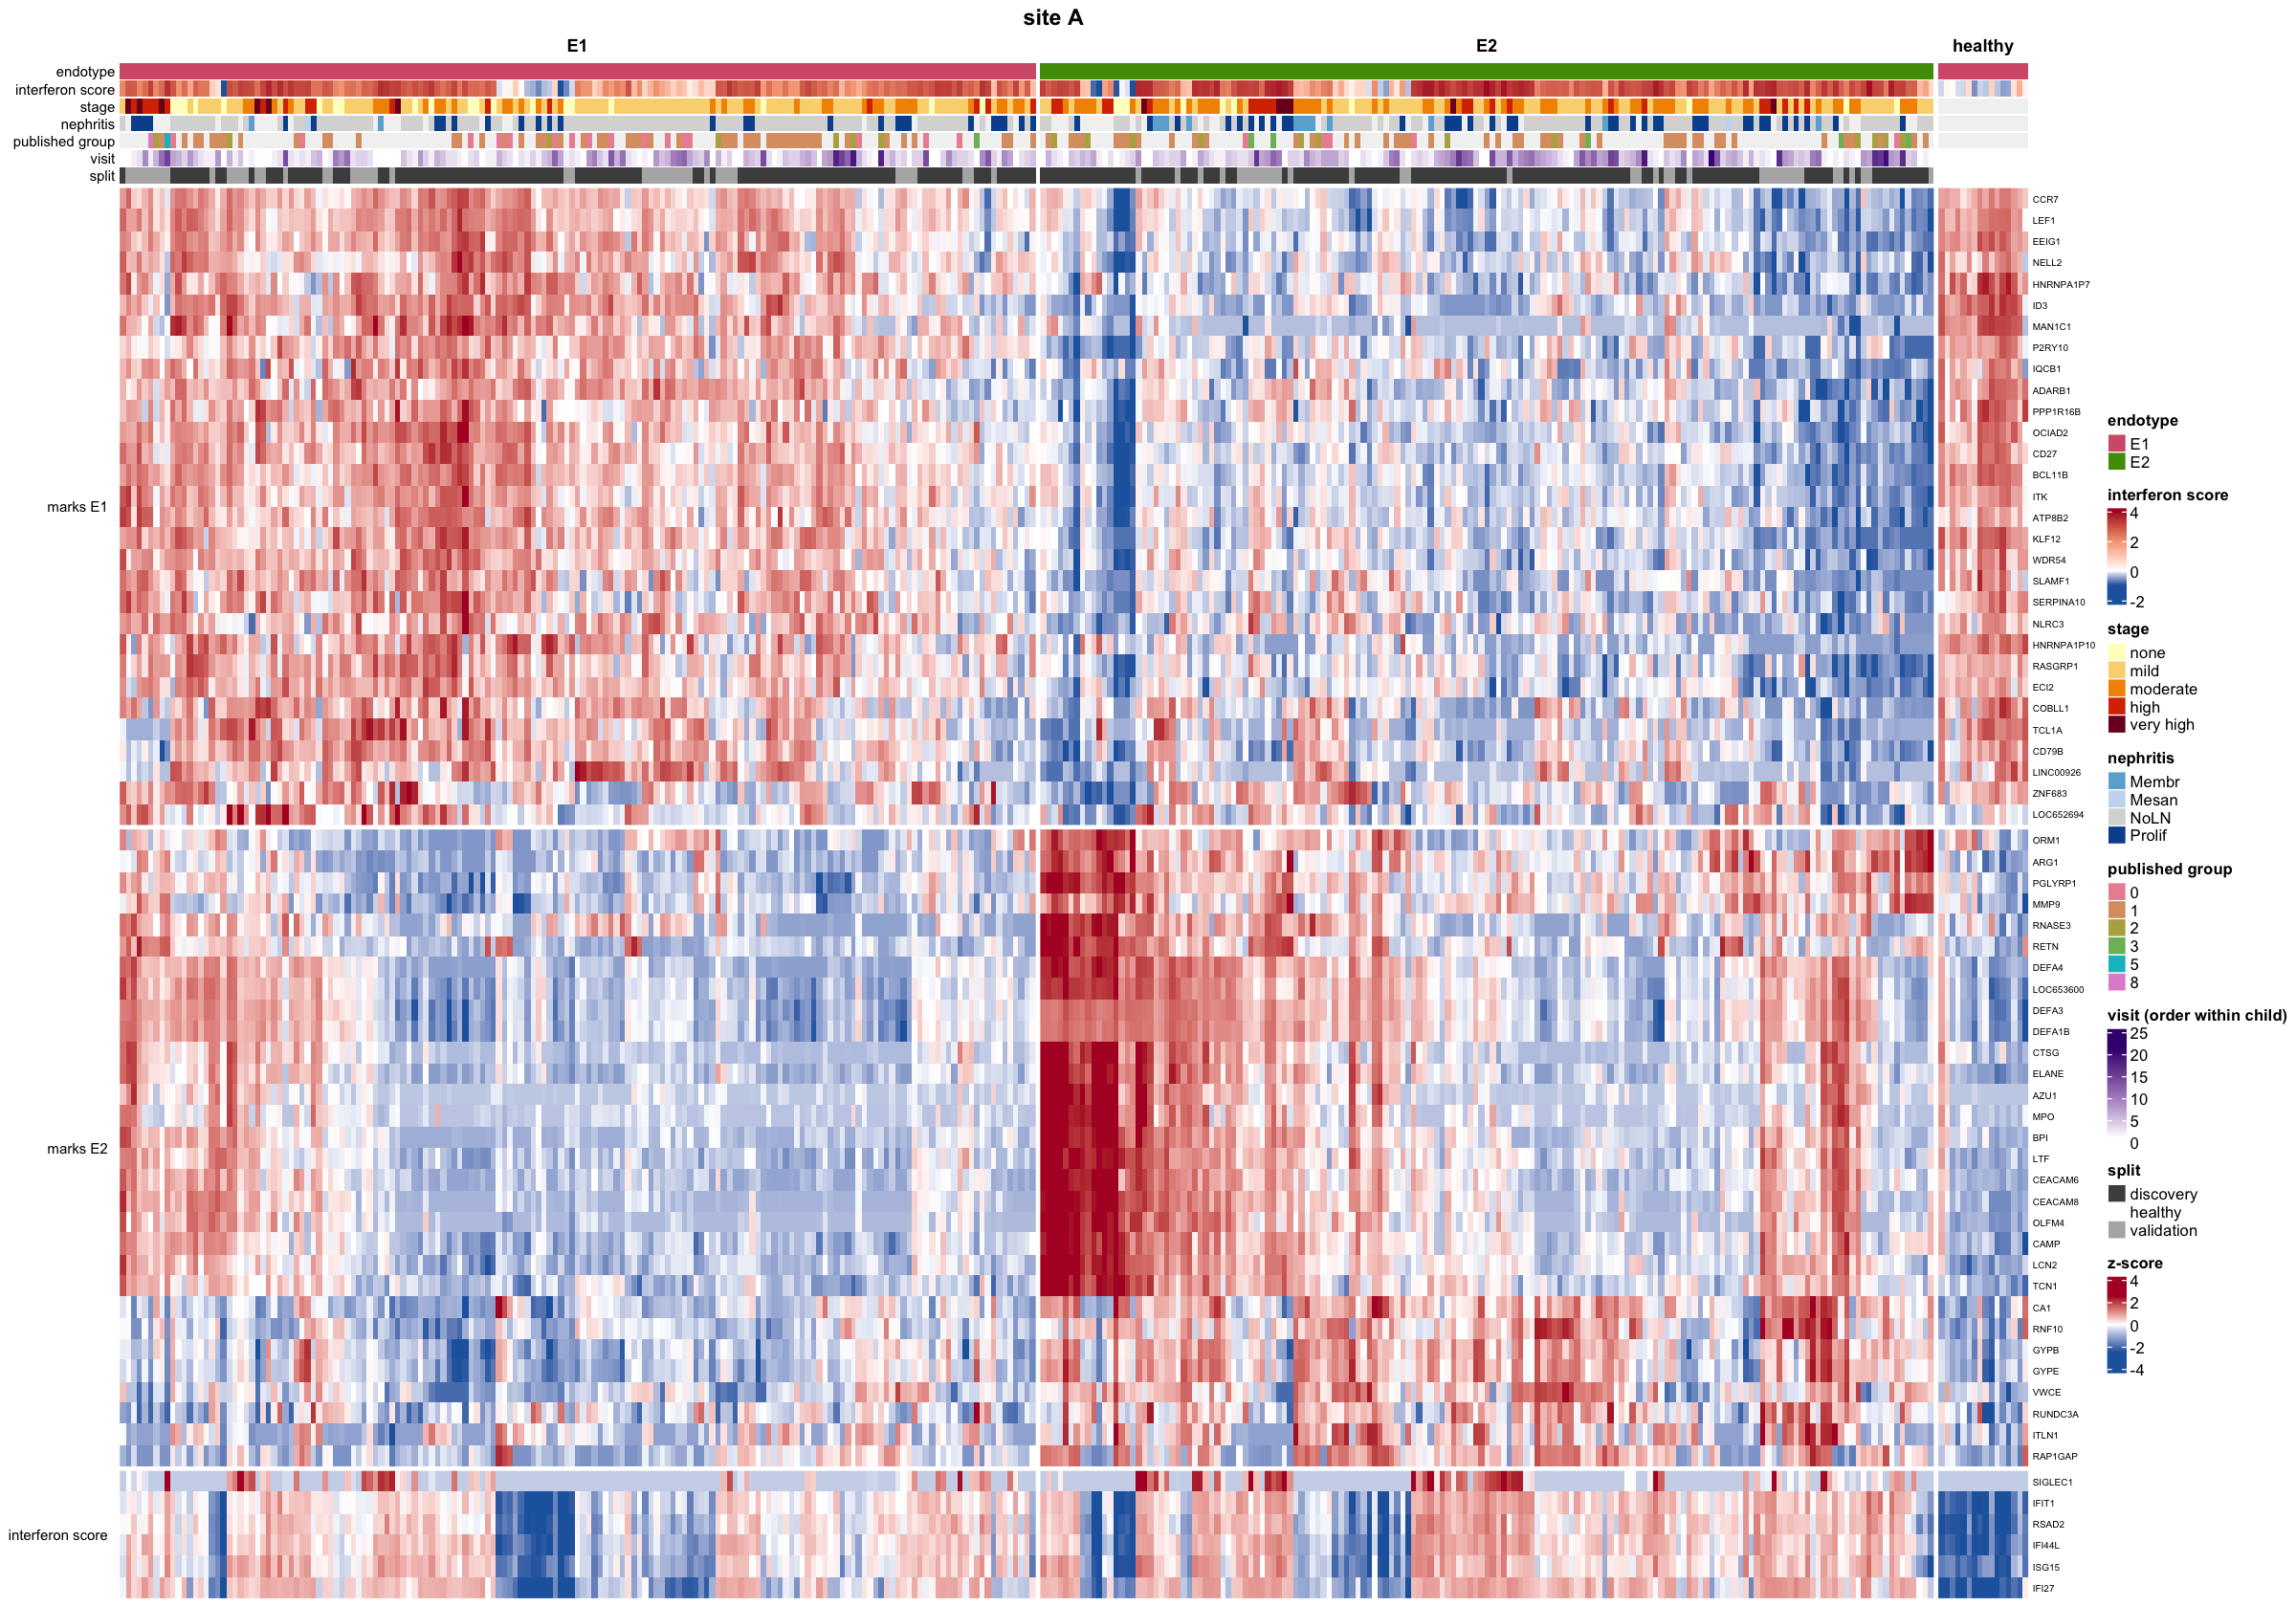

In [3]:
site_heatmap <- function(s) {
  d <- readRDS(site_file("13", s)); m <- d$meta
  M <- (d$E[rows, ] - row_mean) / row_sd
  M[M > 2.5] <- 2.5; M[M < -2.5] <- -2.5
  m$visit_rank <- ave(m$visit, m$subject, FUN = function(v) rank(v, ties.method = "first"))
  block <- factor(ifelse(m$disease == "Healthy", "healthy", as.character(m$endotype)),
                  levels = c(rownames(ce), "healthy"))
  ann <- HeatmapAnnotation(
    endotype = m$endotype, "interferon score" = m$ifn_score, stage = m$stage,
    nephritis = m$nephritis_class, "published group" = m$mdg, visit = m$visit_rank, split = m$split,
    col = list(endotype = EN_COL, "interferon score" = IFN_COL, stage = STAGE_COL, nephritis = NEPH_COL,
               "published group" = MDG_COL, visit = VISIT_COL, split = SPLIT_COL),
    na_col = "grey95", annotation_name_side = "left", annotation_name_gp = gpar(fontsize = 9),
    simple_anno_size = unit(3.5, "mm"),
    annotation_legend_param = list(visit = list(title = "visit (order within child)")))
  Heatmap(M, name = "z-score", col = Z_COL, column_split = block, row_split = row_block[match(rows, rows)],
    cluster_column_slices = FALSE, cluster_row_slices = FALSE,
    clustering_method_columns = "ward.D2", clustering_method_rows = "ward.D2",
    show_column_dend = FALSE, show_row_dend = FALSE, show_column_names = FALSE,
    row_names_gp = gpar(fontsize = 6), row_title_gp = gpar(fontsize = 9), row_title_rot = 0,
    column_title_gp = gpar(fontsize = 11, fontface = "bold"), top_annotation = ann, use_raster = TRUE)
}
for (s in SITES) {
  ht <- site_heatmap(s)
  png(fig("fig15_RNA_array_genes_by_samples_%s.png", s), width = 3000, height = 2300, res = 170)
  draw(ht, merge_legend = TRUE, column_title = paste("site", s), column_title_gp = gpar(fontsize = 14, fontface = "bold"))
  invisible(dev.off())
}
options(repr.plot.width = 20, repr.plot.height = 14)
draw(site_heatmap("A"), merge_legend = TRUE, column_title = "site A", column_title_gp = gpar(fontsize = 14, fontface = "bold"))

Sites B and C are in `figures/fig15_RNA_array_genes_by_samples_B.png` and `..._C.png`.

## Do the endotypes line up with stage? Counts from each site, added up

Each site sends contingency tables: endotype against stage, against nephritis class and against the
published group, over all SLE visits. It sends the same for first visits only, where each child
counts once.

In [4]:
tabs <- lapply(SITES, function(s) {
  m <- readRDS(site_file("13", s))$meta; m <- m[m$disease == "SLE", ]
  f <- m[order(m$subject, m$visit), ]; f <- f[!duplicated(f$subject), ]
  send(list(stage = table(m$stage, m$endotype), nephritis = table(factor(m$nephritis_class, levels = names(NEPH_COL)), m$endotype),
            mdg = table(factor(m$mdg, levels = 0:8), m$endotype),
            stage_first = table(f$stage, f$endotype)),
       s, "contingency tables", nrow(m))
})
TB <- lapply(names(tabs[[1]]), function(k) Reduce(`+`, lapply(tabs, `[[`, k))); names(TB) <- names(tabs[[1]])
round(prop.table(TB$stage, 1), 2)
round(prop.table(TB$nephritis, 1), 2)
TB$mdg

           
              E1   E2
  none      0.58 0.42
  mild      0.58 0.42
  moderate  0.47 0.53
  high      0.39 0.61
  very high 0.38 0.62

             
                E1   E2
  NoLN        0.58 0.42
  Mesan       0.50 0.50
  Membr       0.52 0.48
  Prolif      0.38 0.62
  Proli+Membr 0.67 0.33

   
     E1  E2
  0  42  19
  1 144  97
  2  27  33
  3  10  14
  4   4   2
  5   4   1
  6   0   2
  7   1   0
  8   1   0

In [5]:
TB$stage_first
fisher.test(TB$stage_first, simulate.p.value = TRUE, B = 1e5)

           
            E1 E2
  none       8  6
  mild      30 20
  moderate  29 22
  high      12 14
  very high  9  8


	Fisher's Exact Test for Count Data with simulated p-value (based on
	1e+05 replicates)

data:  TB$stage_first
p-value = 0.8387
alternative hypothesis: two.sided


## Findings

- **E1** is higher in lymphocyte genes: T cell genes (LEF1, BCL11B, ITK, CCR7, ZNF683, RASGRP1) and
  B cell genes (CD79B, CD27, TCL1A). The healthy children look like E1 in these genes.
- **E2** is higher in neutrophil granule genes made by immature neutrophils (LTF, ELANE, MPO, AZU1,
  CTSG, DEFA1B, DEFA3, DEFA4, CAMP, BPI, CEACAM8, LCN2, OLFM4) and in red blood cell genes (GYPB,
  GYPE, CA1).
- **Interferon does not separate them.** The interferon genes are raised in most samples of both
  endotypes and low in the healthy children.
- **Over all visits, E2 becomes more common as SLEDAI rises**, from 42% of visits with no activity to
  61–62% at high or very high activity, and it makes up 62% of visits with proliferative nephritis.
  **At the first visit, one sample per child, there is no association with stage** (Fisher's exact
  test, p = 0.84). The visit-level pattern comes from how children move between endotypes over time
  (step 16), not from a fixed difference between children.
- The published groups overlap only partly: group 0 is mostly E1 (42 of 61), group 2 leans to E2
  (33 of 60), and the large group 1 is split 144 to 97.

The same picture appears at all three sites, and it matches round 1's pooled analysis.